### Analysis Overview

- Compares **tissue contributions** between **PreEclapmsia** and **SeverePreEclapmsia** cohorts for each **deconvolution tool**.  
- Uses **Mann–Whitney U tests** to assess cohort differences within each tool.  
- Produces **boxplots with jittered points** showing ad and SeverePreEclapmsia distributions side by side.  
- Adds **significance brackets and p-value stars** above each pair (based on raw p-values).  
- Saves both **plots (PNG/PDF)** and **statistical summaries (CSV)** for each tissue.


Loaded 868 samples across 7 tools and 2 cohorts.

=== Liver ===
  DeconvolutionTool      pval  BH_adj_p  Significant
0        BayesPrism  0.008008  0.008008         True
1             MuSiC  0.328737  0.328737        False
2             nuSVR  0.639628  0.639628        False
3        CIBERSORTx  0.591582  0.591582        False
4              NNLS  0.113083  0.113083        False
5                QP  0.057728  0.057728        False
6          ReDeconv  0.399715  0.399715        False


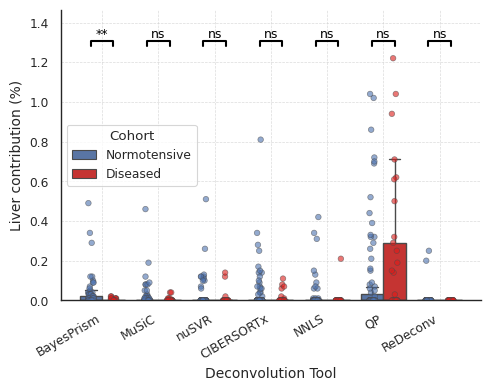


=== Kidney ===
  DeconvolutionTool      pval  BH_adj_p  Significant
0        BayesPrism  0.030854  0.030854         True
1             MuSiC  0.338266  0.338266        False
2             nuSVR  0.292958  0.292958        False
3        CIBERSORTx  0.013586  0.013586         True
4              NNLS  0.599008  0.599008        False
5                QP  0.394803  0.394803        False
6          ReDeconv  0.146963  0.146963        False


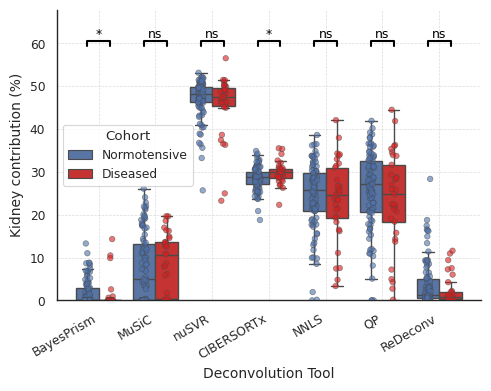


=== Arteries ===
  DeconvolutionTool      pval  BH_adj_p  Significant
0        BayesPrism  0.221533  0.221533        False
1             MuSiC  0.013561  0.013561         True
2             nuSVR  1.000000  1.000000        False
3        CIBERSORTx  1.000000  1.000000        False
4              NNLS  0.029823  0.029823         True
5                QP  0.023288  0.023288         True
6          ReDeconv  0.717431  0.717431        False


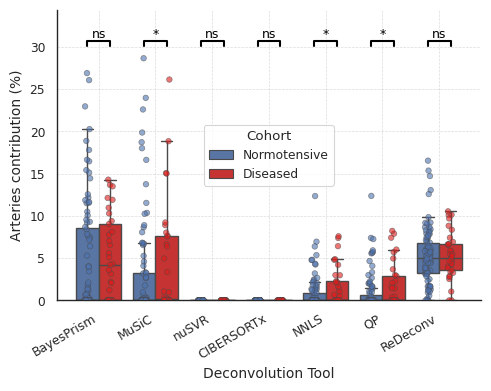


=== Lymphocytes ===
  DeconvolutionTool      pval  BH_adj_p  Significant
0        BayesPrism  0.107092  0.107092        False
1             MuSiC  0.017563  0.017563         True
2             nuSVR  0.602917  0.602917        False
3        CIBERSORTx  0.109578  0.109578        False
4              NNLS  0.569835  0.569835        False
5                QP  0.261394  0.261394        False
6          ReDeconv  0.000507  0.000507         True


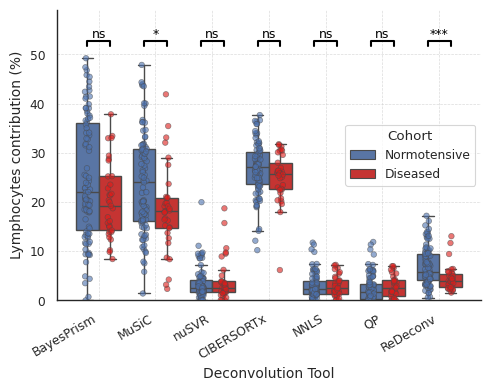


=== Brain ===
  DeconvolutionTool      pval  BH_adj_p  Significant
0        BayesPrism  0.000065  0.000065         True
1             MuSiC  0.001020  0.001020         True
2             nuSVR  0.002630  0.002630         True
3        CIBERSORTx  0.002021  0.002021         True
4              NNLS  0.865307  0.865307        False
5                QP  0.110205  0.110205        False
6          ReDeconv  0.253399  0.253399        False


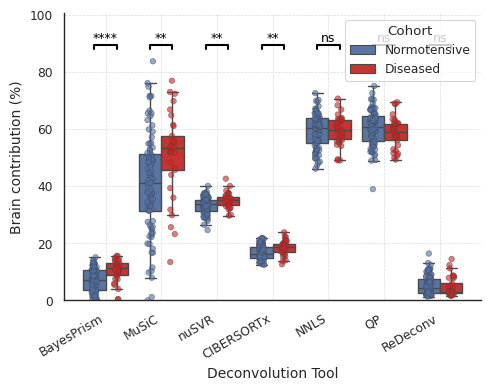


=== Heart ===
  DeconvolutionTool      pval  BH_adj_p  Significant
0        BayesPrism  0.013663  0.013663         True
1             MuSiC  0.146833  0.146833        False
2             nuSVR  0.042530  0.042530         True
3        CIBERSORTx  0.083172  0.083172        False
4              NNLS  0.534963  0.534963        False
5                QP  0.474475  0.474475        False
6          ReDeconv  0.001775  0.001775         True


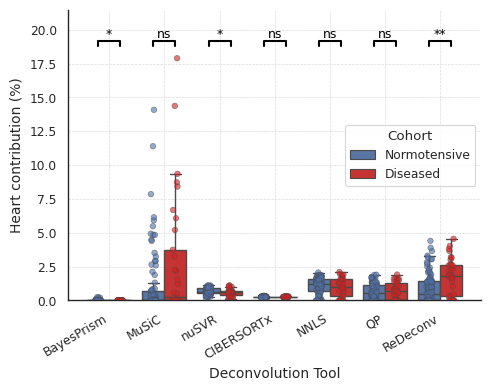

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# ---------- Helper functions ----------
def pval_to_star(p):
    """Convert p-value to significance stars."""
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# ---------- User parameters ----------
tissues_of_interest = ["Liver", "Kidney", "Arteries", "Lymphocytes", "Brain", "Heart"]

tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
palette = {
    "Normotensive": "#4C72B0",   
    "Diseased": "#DD1C1A"      
}

# ---------- Load data ----------
files = {
    "Normotensive": "Decon-Results_Moufarrej_Normotensive_SpecificSample/merged_normalised_results.txt",
    "PreEclapmsia": "Decon-Results_Moufarrej_Pre-Eclampsia_SpecificSample/merged_normalised_results.txt",
    "SeverePreEclapmsia": "Decon-Results_Moufarrej_SeverePre-Eclampsia_SpecificSample/merged_normalised_results.txt"
}

dfs = []
for cohort, path in files.items():
    df = pd.read_csv(path, sep="\t", index_col=0)
    df["Cohort"] = cohort
    dfs.append(df)

merged = pd.concat(dfs)

# Combine both pre-eclampsia groups into one
merged["Cohort"] = merged["Cohort"].replace({
    "PreEclapmsia": "Diseased",
    "SeverePreEclapmsia": "Diseased"
})

# Keep only Diseased and Healthy controls
merged = merged[merged["Cohort"].isin(["Diseased", "Normotensive"])]

print(f"Loaded {merged.shape[0]} samples across {merged['DeconvolutionTool'].nunique()} tools and {merged['Cohort'].nunique()} cohorts.")

# ---------- Long format ----------
long_df = merged.melt(
    id_vars=["DeconvolutionTool", "Cohort"],
    var_name="Tissue",
    value_name="Contribution"
)

# Keep only tissues of interest
long_df = long_df[long_df["Tissue"].isin(tissues_of_interest)]

# ---------- Plot + stats ----------

for tissue in tissues_of_interest:
    df_t = long_df[long_df["Tissue"] == tissue].copy()

    # --- Statistical testing ---
    results = []
    for tool, df_tool in df_t.groupby("DeconvolutionTool"):
        groups = df_tool.groupby("Cohort")["Contribution"].apply(list)
        if set(groups.keys()) == {"Diseased", "Normotensive"}:
            stat, pval = mannwhitneyu(groups["Diseased"], groups["Normotensive"], alternative="two-sided")
            results.append({"DeconvolutionTool": tool, "pval": pval})

    results_df = pd.DataFrame(results)

    # No multiple-testing correction; stars from raw p-values
    if not results_df.empty:
        reject, pvals_corrected, _, _ = multipletests(results_df["pval"], method="fdr_bh")
        results_df["BH_adj_p"] = results_df["pval"]  # keep raw p-values
        results_df["Significant"] = results_df["pval"] < 0.05
    else:
        results_df = pd.DataFrame(columns=["DeconvolutionTool", "pval", "BH_adj_p", "Significant"])

    results_df = results_df.set_index("DeconvolutionTool").reindex(tool_order).reset_index()
    print(f"\n=== {tissue} ===")
    print(results_df)

    # --- Plot ---
    plt.figure(figsize=(5, 4))
    sns.set_theme(style="white")
    sns.set_context("paper", font_scale=1.0)
    
    ax = sns.boxplot(
        data=df_t,
        x="DeconvolutionTool",
        y="Contribution",
        hue="Cohort",
        order=tool_order,
        palette=palette,
        dodge=True,
        showfliers=False
    )

    sns.stripplot(
        data=df_t,
        x="DeconvolutionTool",
        y="Contribution",
        hue="Cohort",
        order=tool_order,
        palette=palette,
        dodge=True,
        jitter=True,
        alpha=0.6,
        linewidth=0.5,
        size=4
    )

    # Remove duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title="Cohort")

    # Get positions for bracket annotations
    xticks = ax.get_xticks()
    xticklabels = [t.get_text() for t in ax.get_xticklabels()]
    tool_to_x = dict(zip(xticklabels, xticks))
    ymax = df_t["Contribution"].max()

    # Draw bracket function
    def PreEclapmsiad_bracket(ax, x1, x2, y, text, height=0.05):
        ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.5, c='black')
        ax.text((x1+x2)/2, y+height, text, ha='center', va='bottom',
                fontsize=9, color='black')

    # Annotate with significance stars
    for _, row in results_df.iterrows():
        tool = row["DeconvolutionTool"]
        if pd.notna(row["BH_adj_p"]) and tool in tool_to_x:
            x = tool_to_x[tool]
            pval = row["BH_adj_p"]
            label = pval_to_star(pval)
            offset = 0.2
            x1, x2 = x - offset, x + offset
            y = ymax * 1.05
            PreEclapmsiad_bracket(ax, x1, x2, y, label, height=ymax * 0.02)

    ax.set_xlabel("Deconvolution Tool", fontsize=10)
    ax.set_ylabel(f"{tissue} contribution (%)", fontsize=10)
    ax.set_ylim(0, ymax * 1.2)
    #ax.set_title(f"{tissue} contribution across cohorts", fontsize=16, fontweight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{tissue}_Diseased_vs_Normotensive_boxplot.svg", format="svg", bbox_inches="tight")
    plt.show()

    # Save stats
    results_df.to_csv(f"{tissue}_Diseased_vs_Normotensive_stats.csv", index=False)
